<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_ejemplo_receta_mlflow.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_ejemplo_receta_mlflow.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_ejemplo_receta_mlflow.ipynb)

# SI7011 · Sesión 02 · Ejemplo resuelto: receta de entrenamiento con MLflow
**Juan David Martínez Vargas · Universidad EAFIT**

Este notebook está **completo**: es el ejemplo que recorremos juntos en clase antes de la Práctica B. Muestra, de principio a fin, las tres etapas con sus artefactos:

| Etapa | Qué se hace aquí | Artefacto |
|---|---|---|
| **Datos** | contrato, ficha, partición y escalado ajustado con entrenamiento | `data_card.json`, escalador |
| **Entrenamiento** | receta configurable (He, AdamW, BatchNorm, Dropout, warmup + coseno, recorte, early stopping) registrada en MLflow | corridas con parámetros, curvas y `best.pt` |
| **Despliegue** | cargar la mejor corrida desde MLflow y predecir sobre filas crudas | `predict_raw` verificado |

**Datos sintéticos.** Usamos `make_classification` de scikit-learn: 30 000 filas, 40 variables, 5 clases. No requiere descargas y corre en CPU en pocos minutos. Las variables tienen escalas muy distintas a propósito, como en un problema real. En la **Práctica B** ustedes aplican la misma receta a Covertype y completan cada pieza.

Lean el código: cada bloque corresponde a una diapositiva de la sesión.

In [1]:
%pip install -q mlflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy, hashlib, json, math, os, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

import mlflow
from mlflow.tracking import MlflowClient

os.environ.setdefault('MLFLOW_DISABLE_AGENT_HINT', '1')
SEED = 42


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed(SEED)
torch.set_num_threads(4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('PyTorch', torch.__version__, '| MLflow', mlflow.__version__, '| device:', device)

/tmp/claude-0/-home-claude-si7011-deeplearning/ac33591d-0957-587f-beaa-6dc7a95bf4fc/scratchpad/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/08 15:14:00 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /tmp/claude-0/-home-claude-si7011-deeplearning/ac33591d-0957-587f-beaa-6dc7a95bf4fc/scratchpad/venv/lib/python3.13/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


PyTorch 2.14.1+cu130 | MLflow 3.17.0 | device: cpu


## 1. Pipeline de datos

### 1.1 Datos crudos
Generamos la tabla y le damos escalas distintas por columna (multiplicamos por factores entre 0.01 y 1000 y desplazamos). Así el escalado deja de ser opcional.

In [3]:
X, y = make_classification(n_samples=30_000, n_features=40, n_informative=20, n_redundant=10, n_classes=5,
                           n_clusters_per_class=2, class_sep=1.0, flip_y=0.02, random_state=SEED)
rng = np.random.default_rng(SEED)
X = X * rng.choice([0.01, 1, 10, 1000], size=40) + rng.normal(0, 50, size=40)
FEATURES = [f'x{i:02d}' for i in range(40)]
df = pd.DataFrame(X, columns=FEATURES).assign(label=y)
C = 5
print(df.shape)
print(df[FEATURES[:6]].describe().loc[['mean', 'std', 'min', 'max']].round(2))

(30000, 41)
       x00       x01     x02    x03    x04       x05
mean -9.25    160.51   53.02  -7.12 -21.63    -88.62
std   0.03   2854.81   27.13   2.82   2.88   7853.12
min  -9.35 -11461.82  -78.49 -18.13 -33.61 -36272.17
max  -9.13  11574.18  162.19   5.22  -9.54  36073.60


### 1.2 Contrato y ficha de datos
El contrato fija columnas, orden y tipo; se vuelve a usar al desplegar. La ficha queda como artefacto de cada corrida.

In [4]:
CONTRACT = {'features': FEATURES, 'target': 'label', 'classes': list(range(C))}


def validate_rows(frame, contract=CONTRACT):
    missing = [c for c in contract['features'] if c not in frame.columns]
    if missing:
        raise ValueError(f'Faltan columnas: {missing[:5]}')
    X = frame[contract['features']]
    if X.isna().any().any() or not all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns):
        raise ValueError('Valores faltantes o columnas no numéricas.')
    return X.to_numpy(dtype=np.float32, copy=True)


X_all = validate_rows(df)
y_all = df['label'].to_numpy().astype(np.int64)
data_card = {'fuente': 'sklearn.make_classification (seed 42)', 'registros': len(df), 'variables': len(FEATURES),
             'clases': np.bincount(y_all).tolist(),
             'sha256': hashlib.sha256(X_all.tobytes()).hexdigest()[:16]}
with open('data_card.json', 'w') as f:
    json.dump(data_card, f, indent=1)
print(json.dumps(data_card, indent=1))

{
 "fuente": "sklearn.make_classification (seed 42)",
 "registros": 30000,
 "variables": 40,
 "clases": [
  5983,
  5982,
  6018,
  5993,
  6024
 ],
 "sha256": "7206f7c275e78bbd"
}


### 1.3 Partición 60/20/20 y escalado sin fuga
El escalador se ajusta **solo** con entrenamiento y se guarda: sin él, el modelo no sirve con datos nuevos.

In [5]:
X_rest, X_test, y_rest, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)
scaler = StandardScaler().fit(X_train)
X_train, X_val, X_test = (scaler.transform(a).astype(np.float32) for a in (X_train, X_val, X_test))
T = {k: torch.as_tensor(v, device=device) for k, v in
     dict(X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train, y_val=y_val, y_test=y_test).items()}
print('entrenamiento', X_train.shape, '| validación', X_val.shape, '| prueba', X_test.shape)

entrenamiento (18000, 40) | validación (6000, 40) | prueba (6000, 40)


## 2. La receta, pieza por pieza

### 2.1 Configuración
Toda la receta vive en un diccionario. MLflow registrará cada valor como parámetro de la corrida.

In [6]:
BASE = dict(depth=8, width=256, init='pytorch', norm='none', dropout=0.0,
            optimizer='sgd', lr=0.05, weight_decay=0.0, schedule='constant', warmup_epochs=0,
            clip_norm=None, epochs=25, batch_size=256, patience=None, seed=SEED)

### 2.2 Modelo e inicialización
Bloque oculto: `Linear → [BatchNorm1d] → ReLU → [Dropout]`. Con BatchNorm el sesgo de `Linear` es redundante. He: $\operatorname{Var}(W)=2/n_\text{in}$.

In [7]:
def make_mlp(cfg, n_in=40, n_out=C):
    bn = cfg['norm'] == 'batchnorm'
    layers, d = [], n_in
    for _ in range(cfg['depth']):
        layers.append(nn.Linear(d, cfg['width'], bias=not bn))
        if bn:
            layers.append(nn.BatchNorm1d(cfg['width']))
        layers.append(nn.ReLU())
        if cfg['dropout'] > 0:
            layers.append(nn.Dropout(cfg['dropout']))
        d = cfg['width']
    layers.append(nn.Linear(d, n_out))
    model = nn.Sequential(*layers)
    if cfg['init'] == 'he':
        for m in model.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    return model


print(make_mlp({**BASE, 'norm': 'batchnorm', 'dropout': 0.1})[:4])

Sequential(
  (0): Linear(in_features=40, out_features=256, bias=False)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
)


### 2.3 Optimizador y learning rate
AdamW aplica el weight decay **desacoplado**. El learning rate sube linealmente durante el warmup y luego baja con un coseno; el scheduler avanza **en cada paso**.

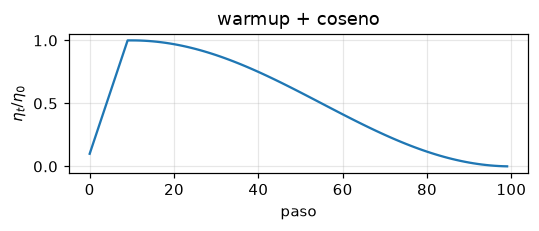

In [8]:
def make_optimizer(model, cfg):
    if cfg['optimizer'] == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.0, weight_decay=cfg['weight_decay'])
    return torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])


def lr_factor(step, total, warmup, schedule):
    if step < warmup:
        return (step + 1) / warmup
    if schedule == 'cosine':
        return 0.5 * (1 + math.cos(math.pi * min(1.0, (step - warmup) / max(1, total - warmup))))
    return 1.0


f = [lr_factor(t, 100, 10, 'cosine') for t in range(100)]
plt.figure(figsize=(5, 2.2)); plt.plot(f); plt.xlabel('paso'); plt.ylabel(r'$\eta_t/\eta_0$'); plt.title('warmup + coseno')
plt.tight_layout(); plt.show()

### 2.4 Una época: medir y recortar el gradiente
`clip_grad_norm_` devuelve la norma **antes** de recortar; con `max_norm=inf` solo mide. Registramos esa norma: es una de las primeras señales de que algo va mal.

In [9]:
def train_one_epoch(model, opt, sched, cfg, gen):
    model.train()
    n = len(T['y_train']); loss_sum, norms = 0.0, []
    for idx in torch.randperm(n, generator=gen).split(cfg['batch_size']):
        idx = idx.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(model(T['X_train'][idx]), T['y_train'][idx])
        loss.backward()
        norms.append(torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['clip_norm'] or float('inf')).item())
        opt.step(); sched.step()
        loss_sum += loss.item() * len(idx)
    return {'train_loss': loss_sum / n, 'grad_norm': float(np.mean(norms)), 'lr': opt.param_groups[0]['lr']}


@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    pred = logits.argmax(1).cpu().numpy(); true = y.cpu().numpy()
    return {'loss': F.cross_entropy(logits, y).item(), 'acc': accuracy_score(true, pred),
            'macro_f1': f1_score(true, pred, average='macro')}, pred

## 3. MLflow: una corrida por receta

`run_experiment` une todo: registra los parámetros, mide la pérdida inicial (verificación $\ln C$), entrena con early stopping, registra las métricas por época y guarda como artefacto un paquete **desplegable**: configuración, pesos, escalador y contrato.

| MLflow | aquí |
|---|---|
| experimento | `S02-ejemplo-receta` |
| parámetros | todo `cfg` |
| métricas por época | `train_loss`, `val_loss`, `val_acc`, `val_macro_f1`, `grad_norm`, `lr` |
| artefactos | `best.pt`, `data_card.json` |

In [10]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')
EXPERIMENT = 'S02-ejemplo-receta'
mlflow.set_experiment(EXPERIMENT)


def run_experiment(cfg, run_name):
    cfg = {**BASE, **cfg}
    set_seed(cfg['seed'])
    model = make_mlp(cfg).to(device)
    opt = make_optimizer(model, cfg)
    spe = math.ceil(len(T['y_train']) / cfg['batch_size'])
    total, warm = cfg['epochs'] * spe, cfg['warmup_epochs'] * spe
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda t: lr_factor(t, total, warm, cfg['schedule']))
    gen = torch.Generator().manual_seed(cfg['seed'])
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(cfg)
        mlflow.log_metric('init_loss', evaluate(model, T['X_train'], T['y_train'])[0]['loss'])
        best, best_state, bad = {'val_loss': float('inf')}, None, 0
        for epoch in range(cfg['epochs']):
            tr = train_one_epoch(model, opt, sched, cfg, gen)
            va, _ = evaluate(model, T['X_val'], T['y_val'])
            row = {**tr, 'val_loss': va['loss'], 'val_acc': va['acc'], 'val_macro_f1': va['macro_f1']}
            mlflow.log_metrics(row, step=epoch)
            if row['val_loss'] < best['val_loss']:
                best, best_state, bad = {**row, 'epoch': epoch}, copy.deepcopy(model.state_dict()), 0
            else:
                bad += 1
            if cfg['patience'] is not None and bad >= cfg['patience']:
                mlflow.set_tag('early_stopped', f'epoch {epoch}')
                break
        mlflow.log_metrics({'best_epoch': best['epoch'], 'best_val_loss': best['val_loss'],
                            'best_val_macro_f1': best['val_macro_f1']})
        torch.save({'cfg': cfg, 'state_dict': best_state, 'contract': CONTRACT,
                    'mean': torch.tensor(scaler.mean_, dtype=torch.float32),
                    'scale': torch.tensor(scaler.scale_, dtype=torch.float32)}, 'best.pt')
        mlflow.log_artifact('best.pt'); mlflow.log_artifact('data_card.json')
    print(f"{run_name:>12s} | mejor época {best['epoch']:2d} | val_loss {best['val_loss']:.4f} | "
          f"F1 macro {best['val_macro_f1']:.3f}")
    return best

2026/10/08 15:14:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/08 15:14:01 INFO mlflow.store.db.utils: Updating database tables


2026/10/08 15:14:02 INFO mlflow.tracking.fluent: Experiment with name 'S02-ejemplo-receta' does not exist. Creating a new experiment.


## 4. Dos recetas: línea base y receta completa

La línea base es un MLP profundo con la inicialización por defecto y SGD sin momentum. La receta aplica **todas** las decisiones de la sesión a la vez. En la Práctica B ustedes las agregan **una por una** para ver el efecto de cada una.

In [11]:
RECIPES = {
    'linea-base': {},
    'receta': dict(init='he', norm='batchnorm', dropout=0.1, optimizer='adamw', lr=1e-3, weight_decay=1e-2,
                   schedule='cosine', warmup_epochs=1, clip_norm=1.0, patience=5),
}
for name, cfg in RECIPES.items():
    run_experiment(cfg, name)

  linea-base | mejor época 24 | val_loss 1.6090 | F1 macro 0.075


      receta | mejor época 20 | val_loss 0.2430 | F1 macro 0.940


## 5. Comparar en MLflow

`mlflow.search_runs` devuelve una tabla con parámetros y métricas finales; `get_metric_history` devuelve la curva completa de una métrica.

In [12]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT], order_by=['attributes.start_time ASC'])
runs = runs.drop_duplicates('tags.mlflow.runName', keep='last').set_index('tags.mlflow.runName')
cols = ['params.init', 'params.optimizer', 'params.norm', 'params.schedule', 'metrics.init_loss',
        'metrics.best_epoch', 'metrics.best_val_loss', 'metrics.best_val_macro_f1']
runs[cols].rename(columns=lambda c: c.split('.', 1)[1]).round(4)

,init,optimizer,norm,schedule,init_loss,best_epoch,best_val_loss,best_val_macro_f1
tags.mlflow.runName,,,,,,,,
linea-base,pytorch,sgd,none,constant,1.6101,24.0,1.609,0.0747
receta,he,adamw,batchnorm,cosine,2.2655,20.0,0.243,0.9403


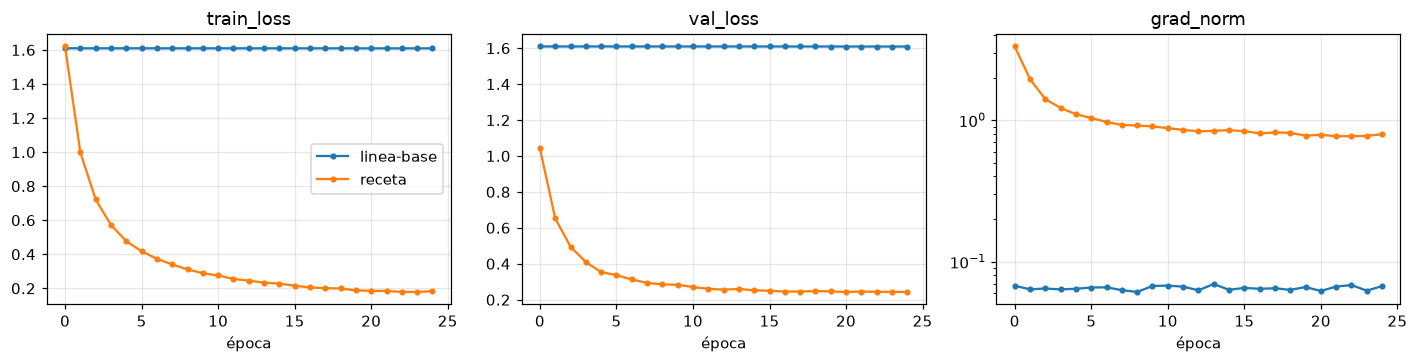

In [13]:
client = MlflowClient()
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for name, run in runs.iterrows():
    for ax, key in zip(axes, ['train_loss', 'val_loss', 'grad_norm']):
        h = client.get_metric_history(run.run_id, key)
        ax.plot([m.step for m in h], [m.value for m in h], marker='.', label=name)
        ax.set_title(key); ax.set_xlabel('época')
axes[2].set_yscale('log'); axes[0].legend()
fig.tight_layout(); plt.show()

**Para comentar en clase.** La línea base queda fija en $\ln 5\approx 1.61$: ¿qué mide `init_loss` y qué dice la norma del gradiente (Práctica A)? ¿Qué cambia en la norma con He, BatchNorm y recorte? ¿Se activó el early stopping de la receta? ¿Qué hace el coseno con la curva al final?

### En la interfaz de MLflow
- **Colab:** la celda siguiente abre la interfaz.
- **Kaggle:** descarga `mlflow.db` y `mlruns/` y ejecuta `mlflow ui --backend-store-uri sqlite:///mlflow.db` en tu computador.
- **Local o Lightning:** ese mismo comando en una terminal, desde la carpeta del notebook.

Selecciona las dos corridas → **Compare**: parámetros lado a lado y curvas superpuestas.

In [14]:
try:
    from google.colab import output
    import subprocess
    subprocess.Popen(['mlflow', 'ui', '--backend-store-uri', 'sqlite:///mlflow.db', '--port', '5000'])
    time.sleep(5)
    output.serve_kernel_port_as_window(5000)
except ImportError:
    print('No estás en Colab: usa `mlflow ui --backend-store-uri sqlite:///mlflow.db` en una terminal.')

No estás en Colab: usa `mlflow ui --backend-store-uri sqlite:///mlflow.db` en una terminal.


## 6. Desplegar desde MLflow

Elegimos con **validación**, evaluamos en prueba **una vez**, y predecimos sobre filas **crudas** usando solo el artefacto: nada de `scaler`, `T` ni `model` del notebook.

In [15]:
chosen = runs.sort_values('metrics.best_val_loss').iloc[0]
ckpt = torch.load(mlflow.artifacts.download_artifacts(run_id=chosen.run_id, artifact_path='best.pt'),
                  map_location='cpu', weights_only=True)
print('Receta elegida por validación:', chosen.name)


@torch.no_grad()
def predict_raw(ckpt, frame):
    X = (torch.as_tensor(validate_rows(frame, ckpt['contract'])) - ckpt['mean']) / ckpt['scale']
    m = make_mlp(ckpt['cfg']); m.load_state_dict(ckpt['state_dict']); m.eval()
    prob = torch.softmax(m(X), dim=1)
    p, idx = prob.max(1)
    return pd.DataFrame({'label': idx.numpy(), 'prob': p.numpy()}, index=frame.index)


raw_test = pd.DataFrame(scaler.inverse_transform(X_test), columns=FEATURES)   # filas crudas de prueba
out = predict_raw(ckpt, raw_test)
model = make_mlp(ckpt['cfg']).to(device); model.load_state_dict(ckpt['state_dict'])
test, pred_test = evaluate(model, T['X_test'], T['y_test'])
print('coincidencia artefacto vs. modelo:', f"{(out['label'].to_numpy() == pred_test).mean():.2%}")
print('prueba (una sola vez):', {k: round(v, 4) for k, v in test.items()})
with mlflow.start_run(run_id=chosen.run_id):
    mlflow.log_metrics({f'test_{k}': v for k, v in test.items()})
print(out.head())

Receta elegida por validación: receta
coincidencia artefacto vs. modelo: 100.00%
prueba (una sola vez): {'loss': 0.2651, 'acc': 0.9282, 'macro_f1': 0.9281}
   label      prob
0      3  0.994690
1      2  0.996918
2      0  0.933149
3      2  0.992960
4      0  0.997763


### Lo que harán en la Práctica B
Las mismas piezas, sobre Covertype (581 mil filas, clases desbalanceadas), pero completadas por ustedes y agregadas **una decisión a la vez** (R0 → R5), con predicciones antes de cada corrida y el despliegue al final. Este notebook es la referencia: si algo no funciona allá, compárenlo con la pieza equivalente aquí.